In [22]:
#Importing dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [24]:
#Opening .csv file 

df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Acccelometer_Gyrometer/preprocessed/preprocessed_typing.csv")
df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,...,task_HoldWeight,task_LiftHold,task_PointFinger,task_Relaxed,task_RelaxedTask,task_StretchHold,task_TouchIndex,task_TouchNose,wrist_LeftWrist,wrist_RightWrist
0,Healthy,1,-1.956550,2.215966,-0.665711,-1.863480,-1.385773,1.054774,0.148228,-1.635454,...,False,False,False,False,False,False,False,False,True,False
1,Healthy,1,-1.440854,1.455673,-0.550948,-1.017312,0.861733,0.812738,0.347888,-0.760231,...,False,False,False,False,False,False,False,False,False,True
2,Healthy,1,-0.057320,0.000288,0.690811,0.169827,-0.335774,0.253703,0.579272,-2.261057,...,False,False,False,False,False,False,False,False,True,False
3,Healthy,1,-0.417996,1.176585,0.510503,-0.917322,0.049310,1.215156,1.426583,-0.595149,...,False,False,False,False,False,False,False,False,False,True
4,Healthy,1,0.040363,-0.561332,-0.419716,0.227308,-0.140380,-0.571669,-0.498113,0.532107,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7805,Parkinson's,469,0.079142,-0.703760,-0.677144,0.259101,-0.195320,-0.659775,-0.530905,0.619259,...,False,False,False,False,False,True,False,False,False,True
7806,Parkinson's,469,2.342317,1.199528,0.662420,-0.344564,0.929031,1.174975,0.217254,-1.192022,...,False,False,False,False,False,False,True,False,True,False
7807,Parkinson's,469,-2.303851,0.605052,-0.199139,-0.356784,1.537547,0.760961,0.144158,-0.223516,...,False,False,False,False,False,False,True,False,False,True
7808,Parkinson's,469,0.275406,0.242516,-0.098475,-0.068806,-0.315676,1.319913,0.197179,-0.352881,...,False,False,False,False,False,False,False,True,True,False


In [25]:
#Checking nulls and label
print(df["condition"].value_counts())

print(df.isnull().sum())

condition
Parkinson's    6072
Healthy        1738
Name: count, dtype: int64
condition               0
patient_id              0
Accelerometer_X_mean    0
Accelerometer_X_std     0
Accelerometer_X_max     0
Accelerometer_X_min     0
Accelerometer_Y_mean    0
Accelerometer_Y_std     0
Accelerometer_Y_max     0
Accelerometer_Y_min     0
Accelerometer_Z_mean    0
Accelerometer_Z_std     0
Accelerometer_Z_max     0
Accelerometer_Z_min     0
Gyroscope_X_mean        0
Gyroscope_X_std         0
Gyroscope_X_max         0
Gyroscope_X_min         0
Gyroscope_Y_mean        0
Gyroscope_Y_std         0
Gyroscope_Y_max         0
Gyroscope_Y_min         0
Gyroscope_Z_mean        0
Gyroscope_Z_std         0
Gyroscope_Z_max         0
Gyroscope_Z_min         0
task_CrossArms          0
task_DrinkGlas          0
task_Entrainment        0
task_HoldWeight         0
task_LiftHold           0
task_PointFinger        0
task_Relaxed            0
task_RelaxedTask        0
task_StretchHold        0
task_TouchInde

In [26]:
#Dropping min and max because they might not be preidctive of the modelm
for col in df.columns:
    if col.endswith("max") or col.endswith("min"):
        df = df.drop(columns = [col])

df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Z_mean,Accelerometer_Z_std,Gyroscope_X_mean,Gyroscope_X_std,...,task_HoldWeight,task_LiftHold,task_PointFinger,task_Relaxed,task_RelaxedTask,task_StretchHold,task_TouchIndex,task_TouchNose,wrist_LeftWrist,wrist_RightWrist
0,Healthy,1,-1.956550,2.215966,-1.385773,1.054774,1.169252,0.656312,-0.716554,0.159633,...,False,False,False,False,False,False,False,False,True,False
1,Healthy,1,-1.440854,1.455673,0.861733,0.812738,1.549047,0.644172,2.052114,0.528431,...,False,False,False,False,False,False,False,False,False,True
2,Healthy,1,-0.057320,0.000288,-0.335774,0.253703,0.395933,-0.074848,-0.073305,0.889236,...,False,False,False,False,False,False,False,False,True,False
3,Healthy,1,-0.417996,1.176585,0.049310,1.215156,1.588708,1.065700,0.111557,2.846592,...,False,False,False,False,False,False,False,False,False,True
4,Healthy,1,0.040363,-0.561332,-0.140380,-0.571669,-0.154085,-0.396890,0.036903,-0.610176,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7805,Parkinson's,469,0.079142,-0.703760,-0.195320,-0.659775,-0.130431,-0.661809,0.073211,-0.633166,...,False,False,False,False,False,True,False,False,False,True
7806,Parkinson's,469,2.342317,1.199528,0.929031,1.174975,0.277188,0.489351,1.557720,0.611903,...,False,False,False,False,False,False,True,False,True,False
7807,Parkinson's,469,-2.303851,0.605052,1.537547,0.760961,-0.013051,0.573294,-0.099431,0.461281,...,False,False,False,False,False,False,True,False,False,True
7808,Parkinson's,469,0.275406,0.242516,-0.315676,1.319913,-0.160955,0.380944,-1.920761,2.681680,...,False,False,False,False,False,False,False,True,True,False


In [34]:
#Balancing the class label with smote

#Defining features and labels 
y = df["condition"]
X = df.drop(columns = ["condition", "patient_id", "wrist_LeftWrist", "wrist_RightWrist"])
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original class distribution:", Counter(y))

smote= SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 42)


Original class distribution: Counter({"Parkinson's": 6072, 'Healthy': 1738})
Resampled class distribution: Counter({'Healthy': 6072, "Parkinson's": 6072})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [35]:
#Training a RF with no hyperparamter
rfc = RandomForestClassifier()

#Fitting and training
rfc.fit(X_train, y_train)
pred = rfc.predict(X_test)

In [37]:
#Eval metrics
print(accuracy_score(y_test, pred))

print(confusion_matrix(y_test, pred))\

print(classification_report(y_test, pred))

0.8419102511321531
[[1050  156]
 [ 228  995]]
              precision    recall  f1-score   support

     Healthy       0.82      0.87      0.85      1206
 Parkinson's       0.86      0.81      0.84      1223

    accuracy                           0.84      2429
   macro avg       0.84      0.84      0.84      2429
weighted avg       0.84      0.84      0.84      2429



In [38]:
#Tuning hyperparamtyers with GridSearCV
from sklearn.model_selection import GridSearchCV, KFold 

k = KFold(n_splits = 5)

param_rfc = {"n_estimators": [50, 100], "max_depth": [4, 8, 12], "min_samples_split": [4, 6], "min_samples_leaf": [2, 4, 6]}

grid_rfc = GridSearchCV(estimator = rfc, cv = k, param_grid=param_rfc)

In [39]:
#Fitting and training the model
grid_rfc.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'max_depth': [4, 8, 12], 'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [4, 6],
                         'n_estimators': [50, 100]})

In [40]:
best_params = grid_rfc.best_params_

print(grid_rfc.best_score_)

0.7600617601646937


In [41]:
#Retrainig model based on performance
rfc_model = RandomForestClassifier(n_estimators = best_params["n_estimators"], max_depth = best_params["max_depth"], min_samples_split = best_params["min_samples_split"], min_samples_leaf = best_params["min_samples_leaf"])

In [42]:
#Fitting and training 
rfc_model.fit(X_train, y_train)
pred_rfc = rfc_model.predict(X_test)

In [43]:
#Eval metrics
print(accuracy_score(y_test, pred_rfc))

print(confusion_matrix(y_test, pred_rfc))

print(classification_report(y_test, pred_rfc))

0.7587484561547962
[[941 265]
 [321 902]]
              precision    recall  f1-score   support

     Healthy       0.75      0.78      0.76      1206
 Parkinson's       0.77      0.74      0.75      1223

    accuracy                           0.76      2429
   macro avg       0.76      0.76      0.76      2429
weighted avg       0.76      0.76      0.76      2429



In [44]:
#Proceeding with feature selection
model_features = rfc_model.feature_importances_

#Creating a new df with the import features and training on the model
pd_features = pd.DataFrame({"Features": X_train.columns, "Feature_importance": model_features}).sort_values(by = "Feature_importance", ascending = False)
pd_features

,Features,Feature_importance
3,Accelerometer_Y_std,0.092538
9,Gyroscope_Y_std,0.088801
7,Gyroscope_X_std,0.085201
6,Gyroscope_X_mean,0.084463
5,Accelerometer_Z_std,0.083432
11,Gyroscope_Z_std,0.083305
1,Accelerometer_X_std,0.081735
2,Accelerometer_Y_mean,0.079682
8,Gyroscope_Y_mean,0.071600
4,Accelerometer_Z_mean,0.068368


/tmp/ipykernel_689948/321612773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


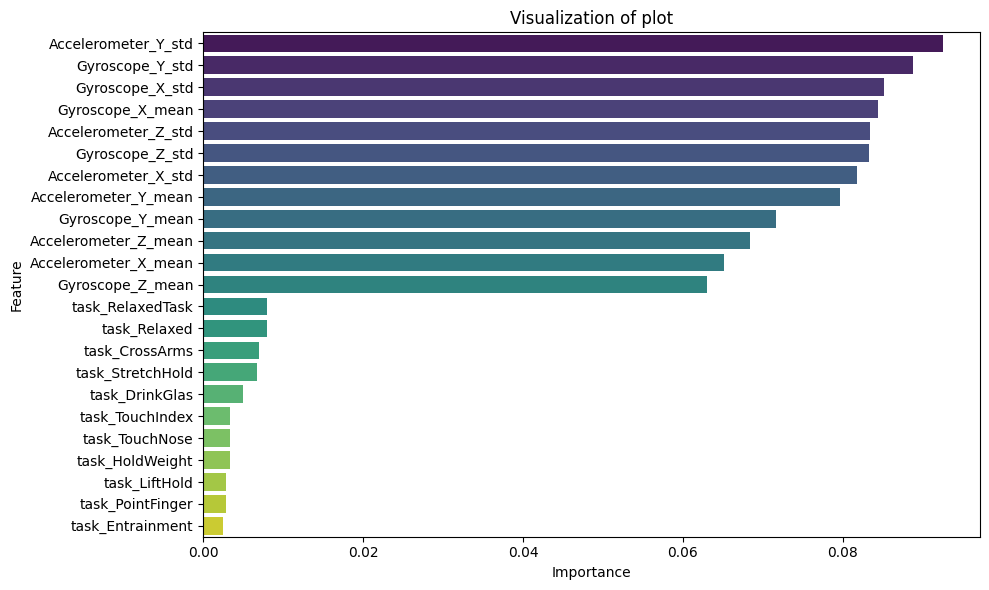

In [45]:
#Visualizations

plt.figure(figsize=(10, 6))
sns.barplot(
    data=pd_features,
    x="Feature_importance",
    y="Features",
    palette="viridis"
)
plt.title("Visualization of plot")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()